# Student Dropout Prediction

## Objective

The objective of this analysis is to develop a machine learning model capable of predicting whether a university student will drop out or successfully graduate based on demographic and academic indicators available early in the academic journey. Multiple machine learning algorithms will be evaluated and compared in order to identify the model that provides the most reliable predictions for early intervention systems.

The analysis follows a structured data science workflow consisting of:

1. Data Understanding
2. Exploratory Data Analysis
3. Data Preparation
4. Model Training
5. Model Evaluation

# 1. Import Libraries

In [143]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score
sns.set(style="whitegrid")

# 2. Load Dataset

The dataset used in this project contains demographic, academic, and socio-economic indicators describing university students. The goal is to predict whether a student will drop out or successfully graduate.

In [144]:
df = pd.read_csv("../datasets/data.csv", sep=";")

# Clean column names
df.columns = df.columns.str.replace("\t", "")
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace("'", "")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mothers qualification,Fathers qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# 3. Dataset Overview

Before building machine learning models, it is important to understand the structure of the dataset.

### Shape

In [145]:
df.shape

(4424, 37)

### Column Names

In [146]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mothers qualification', 'Fathers qualification', 'Mothers occupation',
       'Fathers occupation', 'Admission grade', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)'

### Feature Description

The dataset contains a large number of demographic, academic, and socioeconomic features. 
Describing every feature individually would be impractical, therefore selected key features are highlighted below to provide an overview of the most relevant variables used in the analysis.

| Feature | Description |
|--------|------------|
| Admission grade | Student’s grade at the time of admission |
| Age at enrollment | Age of the student when enrolling |
| Debtor | Indicates whether the student has unpaid tuition fees |
| Tuition fees up to date | Whether the student has paid tuition fees on time |
| Curricular units 1st sem (approved) | Number of courses successfully completed in first semester |
| Curricular units 1st sem (grade) | Average grade in first semester |
| Scholarship holder | Whether the student receives a scholarship |
| Application mode | Method used to apply to the university |

The features can be broadly grouped into the following categories:

- **Demographic features**: Gender, nationality, age
- **Academic performance features**: Grades, approved units, evaluations
- **Administrative/financial features**: Tuition status, debtor status, scholarship
- **Macroeconomic indicators**: GDP, inflation rate, unemployment rate

### Data Types

In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mothers qualification                           4424 non-null   int64  
 9   Fathers qualification                           4424

### Missing Values Check

In [148]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

_The dataset was checked for missing values to ensure data quality before further analysis. The results show that there are no missing values in any of the features. Therefore, no imputation or data cleaning related to missing values is required._

# 4. Target Variable Distribution

The dataset contains three possible outcomes:

- Dropout
- Enrolled
- Graduate

Since the final outcome of "Enrolled" students is unknown, these observations will later be removed from the dataset.

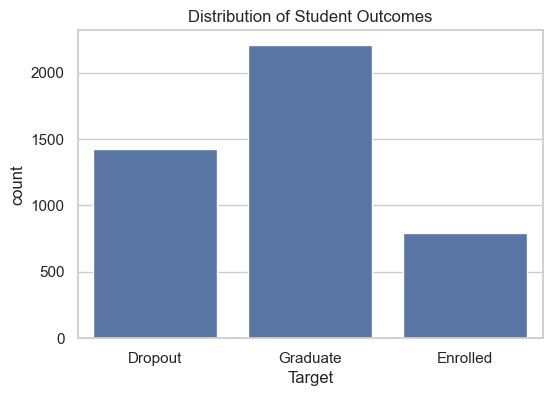

In [149]:
df["Target"].value_counts()

plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=df)
plt.title("Distribution of Student Outcomes")
plt.show()

# 5. Filtering the Dataset

The dataset originally contains three possible academic outcomes: **Dropout**, **Enrolled**, and **Graduate**.

The _Enrolled_ category represents students whose final academic outcome is not yet known. These students may eventually either graduate or drop out in the future. Including these observations in the training data would therefore introduce label uncertainty, because the model would be trained on examples with incomplete outcomes.

To ensure that the model learns only from observations with clearly defined final outcomes, records labeled **Enrolled** are removed from the dataset.

The prediction task therefore becomes a `binary classification problem`:

1 = **Dropout**  
0 = **Graduate**

In [150]:
# Remove whitespace
df["Target"] = df["Target"].str.strip()

df = df[df["Target"] != "Enrolled"]

In [151]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

_After removing the "Enrolled" category, the dataset contains 2209 graduate cases and 1421 dropout cases. Although the classes are not perfectly balanced, the distribution remains sufficiently comparable for standard classification metrics such as accuracy, precision, recall, and F1-score to provide meaningful evaluation._

### Convert Target to Binary

In [152]:
df["Target"] = df["Target"].map({
    "Dropout": 1,
    "Graduate": 0
})

df["Target"].value_counts()

Target
0    2209
1    1421
Name: count, dtype: int64

In [153]:
print(df["Target"].unique())

[1 0]


# 6. Exploratory Data Analysis

Before training machine learning models, exploratory data analysis is conducted to better understand relationships between variables and identify potential predictors of student dropout.

## 6.1. Correlation Analysis

### 6.1.1. Correlation Heatmap

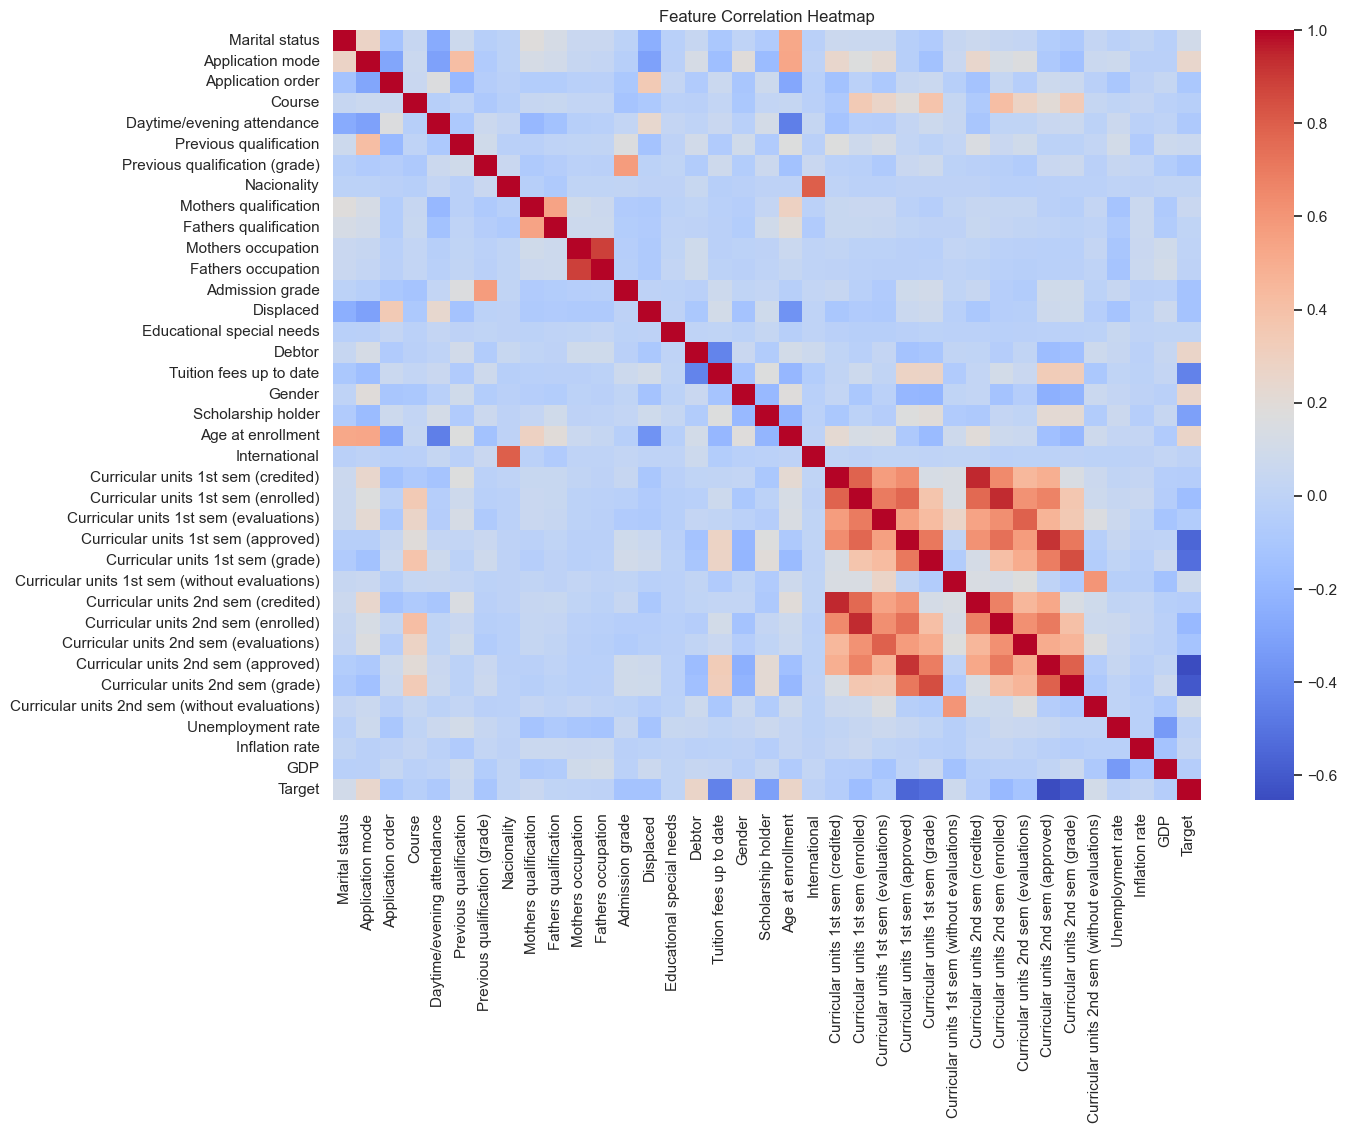

In [154]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

### 6.1.2. Correlation with Target

In [155]:
df.corr()["Target"].drop("Target").sort_values(ascending=False)

Age at enrollment                                 0.267229
Debtor                                            0.267207
Gender                                            0.251955
Application mode                                  0.244507
Curricular units 2nd sem (without evaluations)    0.102687
Marital status                                    0.100479
Curricular units 1st sem (without evaluations)    0.074642
Previous qualification                            0.062323
Mothers qualification                             0.053989
Inflation rate                                    0.030326
Nacionality                                       0.015516
Educational special needs                         0.007254
Fathers qualification                             0.005865
Mothers occupation                               -0.000772
Unemployment rate                                -0.004198
Fathers occupation                               -0.005066
International                                    -0.0061

### 6.1.3. Interpretation

The correlation analysis shows that several academic performance indicators have a relatively strong relationship with the target variable. In particular, variables such as the `number of approved curricular units` and `course grades` show the strongest **negative** correlations with student dropout.

The negative correlations indicate that students who successfully complete more courses and achieve higher grades are less likely to drop out of their academic program. This aligns with expectations, as academic performance is often an important factor in student persistence.

Other variables, including `demographic characteristics` and `macroeconomic indicators`, show relatively **weak** correlations with the target variable. This suggests that these features may have a smaller individual influence on student dropout.

It is also important to note that several second-semester academic indicators show strong correlations with the target variable. However, since the objective of this project is to predict dropout risk early in a student's academic journey, features related to the second semester may introduce `data leakage` and will be considered carefully during the feature selection stage.

Although second-semester variables show strong correlations with the target variable, they are excluded from model training because they would introduce data leakage. These variables would not be available when making early predictions after the first semester.

## 6.2. Feature Relationship Analysis

While correlation analysis provides a general overview of relationships between variables, it does not fully capture how individual features behave across different outcome groups. 

To gain deeper insights, selected key variables are analyzed visually to better understand how they differ between students who graduate and those who drop out.

### 6.2.1. Academic Performance vs Dropout

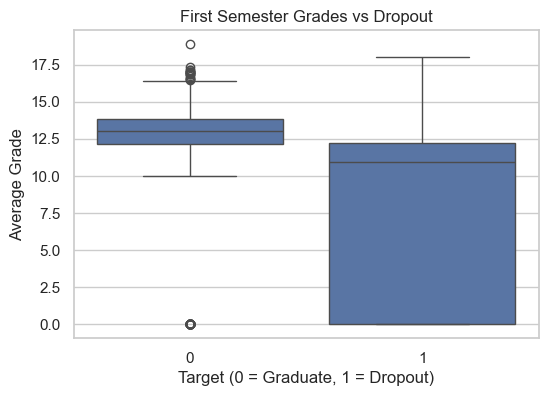

In [156]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Target", y="Curricular units 1st sem (grade)", data=df)

plt.title("First Semester Grades vs Dropout")
plt.xlabel("Target (0 = Graduate, 1 = Dropout)")
plt.ylabel("Average Grade")

plt.show()

The boxplot reveals a clear separation between students who graduate and those who drop out based on first-semester grades. 

Students who graduate (Target = 0) generally achieve higher grades, with a relatively tight distribution centered around higher values. In contrast, students who drop out (Target = 1) show significantly lower median grades and a much wider spread, including a large number of very low or zero grades.

This suggests that poor academic performance early in the program is a strong indicator of future dropout. The presence of many low-grade outliers among dropout students further reinforces the importance of early academic success as a key predictive factor.

### 6.2.2. Tuition Status vs Dropout

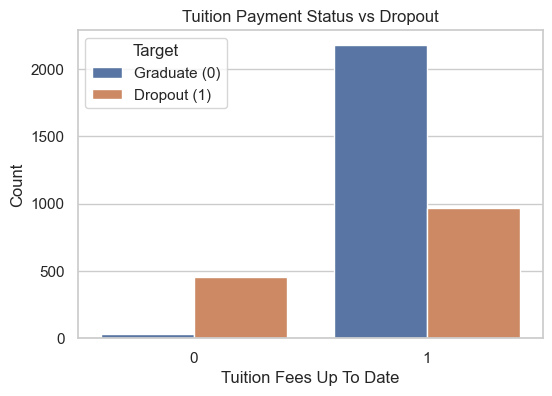

In [157]:
plt.figure(figsize=(6,4))
sns.countplot(x="Tuition fees up to date", hue="Target", data=df)

plt.title("Tuition Payment Status vs Dropout")
plt.xlabel("Tuition Fees Up To Date")
plt.ylabel("Count")

plt.legend(title="Target", labels=["Graduate (0)", "Dropout (1)"])

plt.show()

The distribution of tuition payment status shows a strong relationship with student outcomes. 

Students who are not up to date with their tuition fees (value = 0) have a noticeably higher proportion of dropout cases compared to graduates. In contrast, students who have their tuition fees up to date (value = 1) are more likely to graduate, although some dropout cases still exist within this group.

This pattern indicates that financial stability may play an important role in student retention. Students experiencing financial difficulties may be more likely to discontinue their studies, making tuition payment status a valuable feature for identifying at-risk students.

### 6.2.3. Age vs Dropout

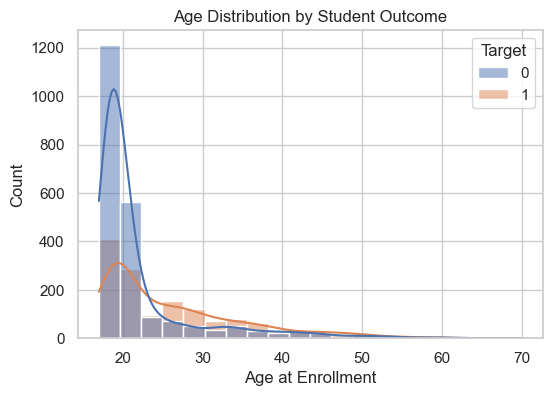

In [158]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Age at enrollment", hue="Target", bins=20, kde=True)

plt.title("Age Distribution by Student Outcome")
plt.xlabel("Age at Enrollment")
plt.ylabel("Count")

plt.show()

The age distribution shows differences between students who graduate and those who drop out. 

Younger students are more concentrated in the graduate group, with a clear peak in the late teens and early twenties. In contrast, dropout students are more widely distributed across age groups, with a higher representation among older students.

This suggests that older students may face additional challenges, such as work commitments or personal responsibilities, which could increase the likelihood of dropping out. While age is not the strongest predictor on its own, it appears to contribute to dropout risk when combined with other factors.

# 7. Data Preparation

Before training machine learning models, the dataset must be prepared. This stage includes removing variables that may introduce data leakage, separating the feature variables from the target variable, and splitting the dataset into training and testing sets.

Since the objective of this project is to predict student dropout early in the academic journey, features related to the second semester will be removed to ensure that the model only uses information that would realistically be available at the time of prediction.

## 7.1. Remove Second Semester Features ( Data Leakage )

In [159]:
# Remove second semester features to avoid data leakage

df = df.drop(columns=[
  "Curricular units 2nd sem (credited)",
  "Curricular units 2nd sem (enrolled)",
  "Curricular units 2nd sem (evaluations)",
  "Curricular units 2nd sem (approved)",
  "Curricular units 2nd sem (grade)",
  "Curricular units 2nd sem (without evaluations)"
])

df.shape

(3630, 31)

## 7.2. Categorical Feature Encoding

Some features in the dataset are categorical but encoded as integers ( e.g., course, nationality, parental occupation ). These do not represent numerical relationships, so one-hot encoding was applied to convert them into binary features. This ensures that the model does not incorrectly assume any ordering between categories.

### 7.2.1. Define X and Y

In [160]:
X = df.drop("Target", axis=1)
y = df["Target"]

### 7.2.2. Define categorical columns

In [161]:
categorical_cols = [
  "Marital status",
  "Application mode",
  "Course",
  "Nacionality",
  "Mothers qualification",
  "Fathers qualification",
  "Mothers occupation",
  "Fathers occupation"
]

### 7.2.3. Apply One-Hot Encoding

In [162]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("New shape:", X.shape)

New shape: (3630, 208)


## 7.3. Train/Test Split

In [163]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (2904, 208)
Test set: (726, 208)


## 7.4. Scale the Data

In [164]:
# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

# 8. Model Experiments

## 8.1. Baseline Model — Logistic Regression

The first model implemented in this analysis is `Logistic Regression`. Logistic Regression is commonly used for binary classification problems and provides a simple and interpretable baseline for evaluating predictive performance.

The goal of this step is to establish an initial benchmark that can later be compared with more complex machine learning models such as **Random Forest** and **Gradient Boosting**.

### 8.1.1. Train the Model

In [165]:
# Initialize the model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 8.1.2. Cross-Validation

In [166]:
log_cv = cross_val_score(
  log_model,
  X_train_scaled,
  y_train,
  cv=5,
  scoring="f1"
)

print("Logistic Regression CV F1:", log_cv)
print("Average CV F1:", log_cv.mean())

Logistic Regression CV F1: [0.85321101 0.84807256 0.82086168 0.83916084 0.84579439]
Average CV F1: 0.8414200962442655


### 8.1.3. Make Predictions

In [167]:
# Predict on the test set
y_pred = log_model.predict(X_test_scaled)

### 8.1.4. Evaluate the Model

In [168]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate ROC-AUC
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_probs)

print("ROC-AUC Score:", roc_auc)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

ROC-AUC Score: 0.944466573194825
Accuracy: 0.8898071625344353
Precision: 0.8422818791946308
Recall: 0.8838028169014085
F1 Score: 0.8625429553264605


### 8.1.5. Confusion Matrix

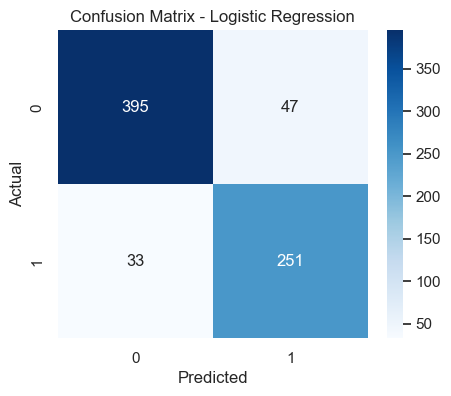

In [169]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### 8.1.6. ROC Curve

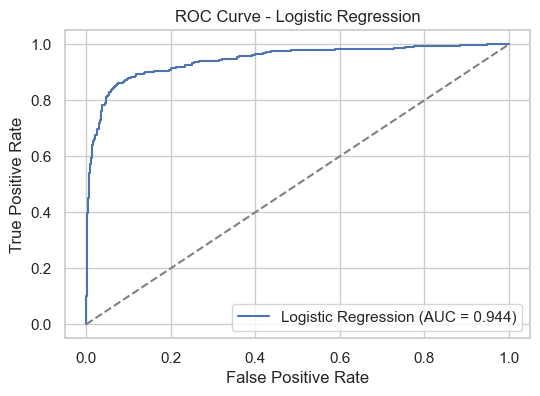

In [170]:
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

### ROC Curve Interpretation

The ROC curve evaluates the ability of the Logistic Regression model to distinguish between students who will drop out and those who will graduate. The model achieves an AUC score of **0.946**, indicating excellent classification performance.

The curve rises steeply near the origin, showing that the model can achieve a high true positive rate while keeping the false positive rate relatively low. This suggests that the model is effective at identifying students at risk of dropping out.

Overall, the high `ROC-AUC` score confirms that the model has strong discriminative power and can reliably differentiate between the two student outcome classes.

### 8.1.7. Model Performance Interpretation

The `Logistic Regression` model achieved an accuracy of approximately **89.5%**, indicating that the majority of student outcomes were correctly classified. This result indicates that a relatively simple linear model is able to capture much of the relationship between the predictors and student dropout.

The confusion matrix shows that the model correctly predicted **406** students who graduated and **244** students who dropped out. However, **36** students were incorrectly predicted as dropouts, while **40** dropout cases were incorrectly classified as graduates.

The recall score of **0.86** indicates that the model successfully identifies approximately **86%** of students who eventually drop out. This is particularly important in the context of early intervention systems, where detecting at-risk students is a key objective.

Overall, the `Logistic Regression` model provides a strong baseline performance that will serve as a reference when evaluating more advanced models in the following sections.

## 8.2. Random Forest Model

`Random Forest` is an ensemble learning algorithm that builds multiple decision trees and aggregates their predictions. It is capable of capturing non-linear relationships between variables and often performs well on tabular datasets.

### 8.2.1 Train the Model

In [171]:
# Initialize the model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 8.2.2. Cross-Validation

Cross-validation is used to evaluate how well the model generalizes to unseen data by training and validating the model across multiple splits of the dataset.

In [172]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Average CV F1:", cv_scores.mean())

Cross-validation F1 scores: [0.84309133 0.83490566 0.82100239 0.81904762 0.84210526]
Average CV F1: 0.832030452822466


### 8.2.3. Make Predictions

In [173]:
# Predict on the test set
rf_pred = rf_model.predict(X_test)

### 8.2.4. Evaluate the Model

In [174]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)

Accuracy: 0.9035812672176309
Precision: 0.8992537313432836
Recall: 0.8485915492957746
F1 Score: 0.8731884057971014


### 8.2.5. Confusion Matrix

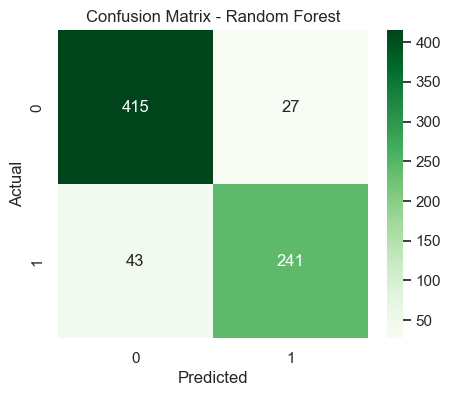

In [175]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

### 8.2.6. ROC Curve

ROC-AUC Score: 0.949684532534574


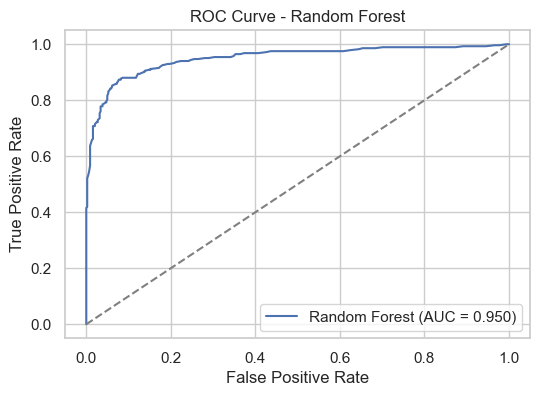

In [176]:
# Calculate predicted probabilities
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
rf_auc = roc_auc_score(y_test, rf_probs)

print("ROC-AUC Score:", rf_auc)

# Compute ROC curve
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,4))

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

_The ROC curve evaluates the ability of the Random Forest model to distinguish between students who drop out and those who graduate. The ROC-AUC score indicates strong classification performance, suggesting that the model effectively separates the two outcome classes._

### 8.2.7. Feature Importance

In [177]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances.head(10))

Curricular units 1st sem (approved)       0.192335
Curricular units 1st sem (grade)          0.116838
Tuition fees up to date                   0.065658
Curricular units 1st sem (evaluations)    0.049759
Age at enrollment                         0.048601
Admission grade                           0.039940
Previous qualification (grade)            0.036160
Scholarship holder                        0.029121
Curricular units 1st sem (enrolled)       0.026545
Debtor                                    0.023405
dtype: float64


_The high importance of first-semester approved curricular units suggests that early academic performance plays a dominant role in predicting student dropout risk._

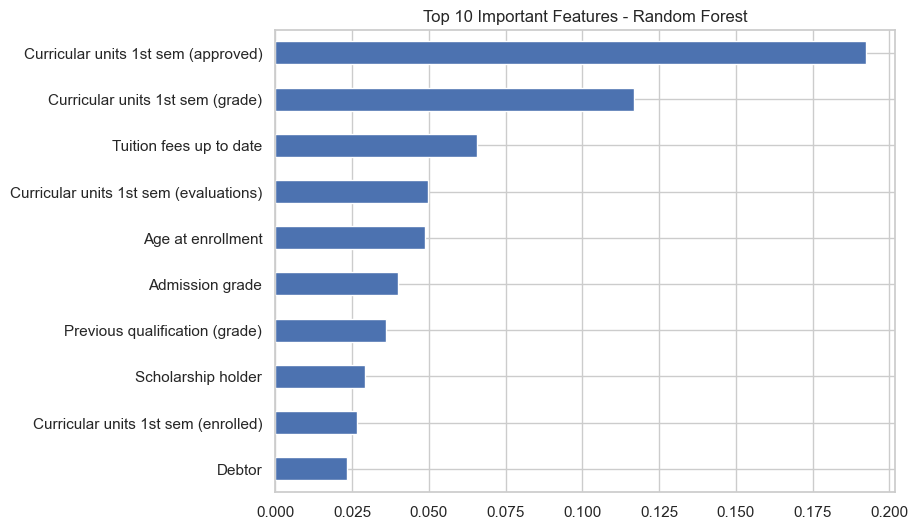

In [178]:
plt.figure(figsize=(8,6))
importances.head(10).plot(kind="barh")

plt.title("Top 10 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.show()

### 8.2.7. Model Performance Interpretation

The `Random Forest` model achieved an accuracy of approximately **89.8%**, which is slightly higher than the `Logistic Regression baseline`. The model also achieved a precision score of **0.88**, a recall score of **0.85**, and an F1-score of **0.87**.

The confusion matrix shows that the model correctly classified **410** students who graduated and **242** students who dropped out. However, **42** dropout cases were incorrectly predicted as graduates, while **32** graduates were incorrectly classified as dropouts.

The recall score of **0.85** indicates that the model successfully identifies approximately **85%** of students who eventually drop out. This performance is comparable to the Logistic Regression model, suggesting that the relationships between the variables and the target outcome may be relatively `linear`.

The cross-validation results show relatively stable F1 scores across the five folds, with an average F1-score of approximately **0.84**. This indicates that the Random Forest model generalizes well to unseen data and does not appear to suffer from significant overfitting.

Feature importance analysis reveals that first-semester academic performance indicators are the strongest predictors of student dropout. In particular, the number of approved curricular units and first-semester grades appear to have the greatest influence on the model’s predictions. These findings align with the domain research, which suggests that early academic performance is a strong indicator of student persistence.

Overall, the `Random Forest` model provides a slight improvement over the Logistic Regression baseline while offering additional insights into the relative importance of different features.

## 8.3. Gradient Boosting

Gradient Boosting is an ensemble learning algorithm that builds models sequentially, where each new model attempts to correct the errors made by the previous ones. Unlike `Random Forest`, which builds trees independently, `Gradient Boosting` improves predictions iteratively and often achieves strong performance on structured tabular datasets.

### 8.3.1 Train the Model

In [179]:
# Initialize the model
gb_model = GradientBoostingClassifier(
  n_estimators=200, #number of trees
  learning_rate=0.05, #how much each tree contributes to the final prediction
  random_state=42 #reproducibility
)

# Train the model
gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

### 8.3.2 Make Predictions

In [180]:
# Predict on the test set
gb_pred = gb_model.predict(X_test)

### 8.3.3 Evaluate the Model

In [181]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)

print("Accuracy:", gb_accuracy)
print("Precision:", gb_precision)
print("Recall:", gb_recall)
print("F1 Score:", gb_f1)

Accuracy: 0.9049586776859504
Precision: 0.8798586572438163
Recall: 0.8767605633802817
F1 Score: 0.8783068783068783


### 8.3.4 Confusion Matrix

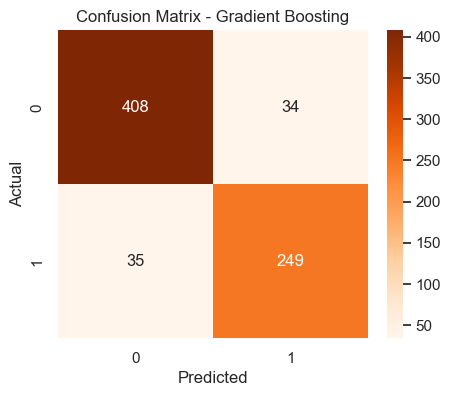

In [182]:
gb_cm = confusion_matrix(y_test, gb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(gb_cm, annot=True, fmt="d", cmap="Oranges")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gradient Boosting")

plt.show()

### 8.3.5. ROC Curve

ROC-AUC Score: 0.9546475686699382


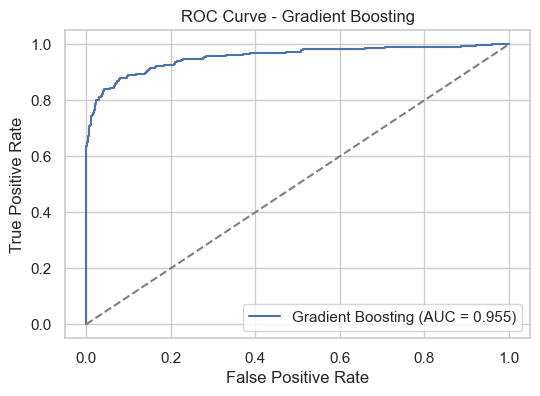

In [183]:
# Calculate predicted probabilities
gb_probs = gb_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
gb_auc = roc_auc_score(y_test, gb_probs)

print("ROC-AUC Score:", gb_auc)

# Compute ROC curve
gb_fpr, gb_tpr, thresholds = roc_curve(y_test, gb_probs)

plt.figure(figsize=(6,4))

plt.plot(gb_fpr, gb_tpr, label=f"Gradient Boosting (AUC = {gb_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()

plt.show()

_The ROC curve shows the classification performance of the Gradient Boosting model across different decision thresholds. The ROC-AUC score indicates strong discriminative ability, meaning the model can effectively differentiate between students who are likely to drop out and those who are likely to graduate._

### 8.3.6. Model Performance Interpretation

The `Gradient Boosting` model achieved an accuracy of approximately **89.7%**, with a precision score of **0.88**, a recall score of **0.86**, and an F1-score of **0.87**. These results indicate that the model performs comparably to both the Logistic Regression and Random Forest models.

The confusion matrix shows that the model correctly classified **408** students who graduated and **243** students who dropped out. However, **41** dropout cases were incorrectly predicted as graduates, while **34** graduates were incorrectly classified as dropouts.

The recall score of 0.86 indicates that the model successfully identifies approximately **86%** of students who eventually drop out. Since the primary objective of this predictive system is early detection of at-risk students, recall remains an important metric for evaluating model effectiveness.

Compared with the other models tested in this analysis, the `Gradient Boosting` model performs very similarly. This suggests that the relationships between the predictors and student dropout risk may be relatively well captured by both linear and ensemble methods.

Overall, the `Gradient Boosting` model provides strong predictive performance while maintaining balanced precision and recall, making it a competitive candidate for predicting student dropout risk.

# 9. Model Comparison

In this section, the performance of the different machine learning models is compared using the evaluation metrics calculated earlier. The goal is to determine which model provides the most reliable predictions for identifying students at risk of dropping out.

## 9.1. Comparison Table

In [184]:
results = pd.DataFrame({
  "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
  "Accuracy": [accuracy, rf_accuracy, gb_accuracy],
  "Precision": [precision, rf_precision, gb_precision],
  "Recall": [recall, rf_recall, gb_recall],
  "F1 Score": [f1, rf_f1, gb_f1],
  "ROC-AUC": [roc_auc, rf_auc, gb_auc]
})

results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.904959,0.879859,0.876761,0.878307,0.954648
1,Random Forest,0.903581,0.899254,0.848592,0.873188,0.949685
0,Logistic Regression,0.889807,0.842282,0.883803,0.862543,0.944467


## 9.2. Model Performance Visualization

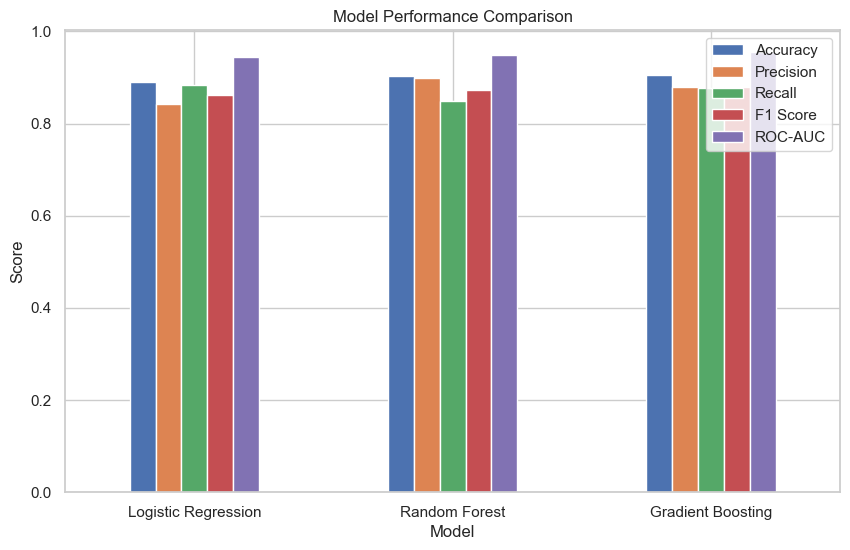

In [185]:
results.set_index("Model").plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

## 9.3. Model Comparison Interpretation

The relatively small differences between the models suggest that the relationships between the predictors and student dropout risk may be largely linear. This explains why the simpler Logistic Regression model performs nearly as well as the more complex ensemble models. This observation indicates that early academic indicators already provide strong predictive signals, allowing even simpler models such as Logistic Regression to perform nearly as well as more complex ensemble models.

# 10. Ethical Feature Analysis

In this section, an additional experiment is conducted to evaluate the impact of removing sensitive demographic attributes from the model. Variables such as gender, nationality, and parental education or occupation may introduce social or cultural bias into predictive systems. To examine their influence, the models are retrained without these attributes and their performance is compared with the previous results.

According to the **EU Ethics Guidelines for Trustworthy AI**, predictive systems should avoid discriminatory outcomes and ensure fairness when demographic attributes are involved.

European Commission. (2019).
Ethics Guidelines for Trustworthy AI.
https://digital-strategy.ec.europa.eu/en/library/ethics-guidelines-trustworthy-ai

European Union. (2016).
General Data Protection Regulation (GDPR).
https://gdpr-info.eu/

## 10.1. Criteria for Identifying Sensitive Features

When building predictive systems that may influence educational decisions, it is important to consider the ethical implications of the features used for training machine learning models. Certain variables may represent **demographic identity** or **socioeconomic background**, which can introduce unfair bias in automated decision systems.

According to ethical guidelines for trustworthy AI and the principles of responsible data use, features may be considered sensitive if they:

• Represent **demographic identity** (e.g., gender or nationality)  
• Represent **family socioeconomic background** (e.g., parents’ education or occupation)  
• Could act as **proxies for protected characteristics**  
• May not be appropriate to use in real-world predictive systems due to **data protection regulations such as the EU General Data Protection Regulation (GDPR)**.

The goal of this analysis is therefore to identify whether any variables in the dataset fall into these categories and evaluate their potential impact on model predictions.

## 10.2. Identification of Potentially Sensitive Features

Based on the dataset structure, several variables describe either **demographic identity** or **family socioeconomic background** rather than academic performance. These variables may introduce ethical concerns if used directly in predictive models.

The following features are therefore identified as potentially sensitive:

• Gender  
• Nacionality  
• Mothers qualification  
• Fathers qualification  
• Mothers occupation  
• Fathers occupation  

These variables describe characteristics related to a student's demographic identity or family background rather than their academic performance. As a result, predictive models trained with these attributes may learn patterns that reflect social or economic inequalities instead of academic factors directly related to student success.

### Sensitive Feature Justification

| Feature | Category | Ethical Concern |
|--------|----------|----------------|
| Gender | Demographic identity | Potential risk of gender-related bias |
| Nacionality | Demographic identity | Possible bias toward majority nationality groups |
| Mothers qualification | Socioeconomic background | Proxy for family education level |
| Fathers qualification | Socioeconomic background | Proxy for family education level |
| Mothers occupation | Socioeconomic background | Proxy for household income |
| Fathers occupation | Socioeconomic background | Proxy for household income |

These variables describe characteristics related to a student's background rather than their academic progress. Their use in predictive models may therefore raise ethical concerns regarding fairness and potential discrimination.

## 10.3. Data Governance and Privacy Considerations

In addition to fairness concerns, practical data governance constraints must also be considered when designing predictive systems for real-world educational environments.

Universities may not always be able to collect or use certain personal attributes without explicit student consent. Variables such as parental occupation, parental education, nationality, or gender may be considered sensitive personal information under regulations such as the **European General Data Protection Regulation (GDPR)**.

Furthermore, the principle of **data minimization** suggests that predictive models should rely only on information that is strictly necessary for the intended purpose. Since the objective of this model is to identify academic risk factors related to student performance, demographic and family background variables may not be required for accurate prediction.

For this reason, it is important to investigate whether similar predictive performance can be achieved without relying on these sensitive attributes.

## 10.4. Distribution of Sensitive Features

In [186]:
sensitive_features = [
  "Gender",
  "Nacionality",
  "Mothers qualification",
  "Fathers qualification",
  "Mothers occupation",
  "Fathers occupation"
]

for feature in sensitive_features:
  print(f"\nTop categories for {feature}:")
  print(df[feature].value_counts().head(10))


Top categories for Gender:
Gender
0    2381
1    1249
Name: count, dtype: int64

Top categories for Nacionality:
Nacionality
1      3544
41       32
22       12
26        9
6         8
24        5
103       3
11        3
101       2
100       2
Name: count, dtype: int64

Top categories for Mothers qualification:
Mothers qualification
1     865
37    840
19    777
38    471
3     337
34    127
2      60
12     39
4      34
5      16
Name: count, dtype: int64

Top categories for Fathers qualification:
Fathers qualification
37    1010
19     785
1      732
38     575
3      220
34     109
2       43
12      34
4       32
5       15
Name: count, dtype: int64

Top categories for Mothers occupation:
Mothers occupation
9     1313
4      670
5      436
3      272
2      240
7      224
0      143
1       87
6       77
90      70
Name: count, dtype: int64

Top categories for Fathers occupation:
Fathers occupation
9     847
7     555
5     409
3     321
4     312
8     263
10    212
6     194
2 

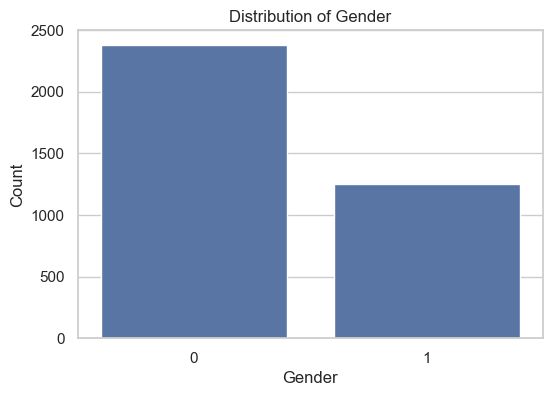

In [187]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender", data=df)

plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

_The distribution analysis shows how demographic attributes are represented in the dataset. Understanding the balance of these groups is important because highly imbalanced distributions may cause models to learn biased patterns that favour the majority group._

## 10.5. Relationship Between Sensitive Features and Dropout

In [188]:
for feature in sensitive_features:
  print(f"\nDropout rate by {feature}:")
  print(df.groupby(feature)["Target"].mean())


Dropout rate by Gender:
Gender
0    0.302394
1    0.561249
Name: Target, dtype: float64

Dropout rate by Nacionality:
Nacionality
1      0.391930
2      0.000000
6      0.500000
11     0.000000
13     0.000000
14     0.000000
17     1.000000
21     1.000000
22     0.333333
24     0.200000
25     0.000000
26     0.111111
41     0.437500
62     0.000000
100    1.000000
101    0.500000
103    0.333333
105    1.000000
109    1.000000
Name: Target, dtype: float64

Dropout rate by Mothers qualification:
Mothers qualification
1     0.346821
2     0.333333
3     0.412463
4     0.235294
5     0.500000
6     0.750000
9     0.625000
10    0.666667
11    0.666667
12    0.564103
14    0.500000
18    1.000000
19    0.348777
22    0.000000
26    0.000000
27    1.000000
29    0.333333
30    0.333333
34    0.755906
35    0.666667
36    0.666667
37    0.455952
38    0.297240
39    0.666667
40    0.375000
41    0.333333
42    0.500000
43    0.333333
44    1.000000
Name: Target, dtype: float64

Dropout r

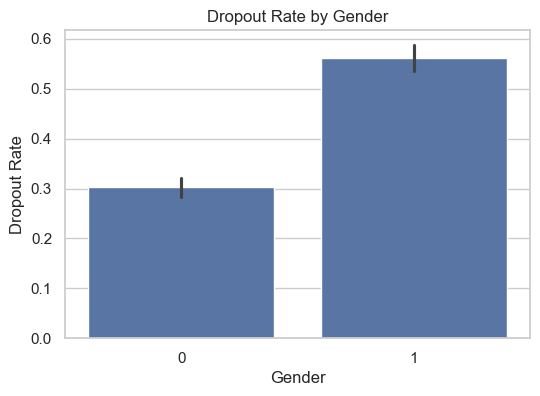

In [189]:
gender_dropout = df.groupby("Gender")["Target"].mean()

plt.figure(figsize=(6,4))
sns.barplot(x="Gender", y="Target", data=df)

plt.title("Dropout Rate by Gender")
plt.ylabel("Dropout Rate")

plt.show()

The analysis shows that several demographic attributes display different dropout rates across groups.

In particular, `gender` shows a noticeable difference in dropout probability, where one group has a dropout rate of approximately **56%**, compared with approximately **30%** for the other group. This suggests that predictive models may learn patterns associated with gender.

It is important to note that differences in dropout rates across demographic groups do not necessarily indicate `discriminatory behaviour` in the predictive model. However, these differences suggest that demographic attributes may influence model predictions in ways that raise ethical considerations when such systems are used in decision-support contexts.

Nationality shows a highly imbalanced distribution, with the majority of observations belonging to a single category. Several other nationality groups contain very few observations, making their calculated dropout rates statistically unreliable.

Parental education and occupation variables contain many categorical levels representing different socioeconomic backgrounds. These attributes may act as proxies for family socioeconomic status and therefore introduce unintended bias into predictive models.

## 10.6 Proxy Variables and Indirect Bias

Even when sensitive demographic attributes are removed from a dataset, other variables may still indirectly encode similar information. These variables are often referred to as **proxy variables**.

For example, certain academic programs or socioeconomic indicators may correlate with demographic characteristics such as `gender` or `nationality`. As a result, removing sensitive attributes does not completely eliminate the possibility of bias in machine learning models.

However, excluding these attributes represents an important step toward reducing the likelihood that predictive models rely directly on demographic identity when making predictions.

## 10.7. Ethical Feature Selection Decision

Based on the previous analysis, several demographic and socioeconomic variables have been identified as potentially sensitive attributes. These features may influence predictive outcomes in ways that raise ethical concerns related to fairness and discrimination.

To evaluate whether similar predictive performance can be achieved without relying on demographic attributes, a second set of models will be trained without these features.

The following variables will therefore be removed from the training dataset when constructing the ethical models:

  • Gender  
  • Nacionality  
  • Mothers qualification  
  • Fathers qualification  
  • Mothers occupation  
  • Fathers occupation  

The models trained without these variables will be referred to as `ethical models`, and their performance will be compared with the original models trained on the full dataset.

# 11. Ethical Model Training

In this section, a second set of models is trained using a dataset that excludes the sensitive features identified during the ethical feature analysis.

The purpose of this experiment is to evaluate whether comparable predictive performance can be achieved without relying on demographic or socioeconomic attributes. Removing such variables may help reduce the risk of bias and improve the ethical suitability of the predictive system in real-world educational environments.

The following sensitive attributes are removed from the dataset:

• Gender  
• Nacionality  
• Mothers qualification  
• Fathers qualification  
• Mothers occupation  
• Fathers occupation  

The resulting models will be referred to as **ethical models**, and their performance will later be compared with the original models trained using the full dataset.

## 11.1. Ethical Dataset Preparation

To construct the ethical dataset, the sensitive demographic and socioeconomic features identified in Section 10 are removed from the feature matrix.

This ensures that the models rely only on academic, administrative, and macroeconomic indicators that are less likely to introduce demographic bias.

The resulting dataset is then used to retrain the machine learning models.

### 11.1.1. Define Sensitive Features

In [190]:
# Sensitive prefixes identified during ethical analysis
sensitive_prefixes = [
  "Gender",
  "Nacionality",
  "Mothers qualification",
  "Fathers qualification",
  "Mothers occupation",
  "Fathers occupation"
]

### 11.1.2. Create Ethical Dataset

In [191]:
cols_to_drop = [
  col for col in X.columns
  if any(col.startswith(prefix) for prefix in sensitive_prefixes)
]

X_eth = X.drop(columns=cols_to_drop)

print("Original number of features:", X.shape[1])
print("Ethical dataset number of features:", X_eth.shape[1])

Original number of features: 208
Ethical dataset number of features: 59


_Six sensitive demographic and socioeconomic attributes were removed from the dataset, resulting in a reduced feature set used for training the ethical models._

### 11.1.3. Verify Removed Features

In [192]:
print("Removed sensitive features:")
for feature in sensitive_features:
  print("-", feature)

Removed sensitive features:
- Gender
- Nacionality
- Mothers qualification
- Fathers qualification
- Mothers occupation
- Fathers occupation


### 11.1.4. Check Correlation With Target

In [193]:
# Check strongest predictors after removing sensitive attributes
X_eth.corrwith(y).abs().sort_values(ascending=False).head(10)

Curricular units 1st sem (approved)    0.554881
Curricular units 1st sem (grade)       0.519927
Tuition fees up to date                0.442138
Scholarship holder                     0.313018
Age at enrollment                      0.267229
Debtor                                 0.267207
Application mode_39                    0.255597
Course_9500                            0.208112
Course_9119                            0.169308
Curricular units 1st sem (enrolled)    0.161074
dtype: float64

_The correlation analysis shows that the strongest predictors of student dropout remain primarily related to academic performance indicators, such as the number of approved curricular units and first semester grades. This indicates that removing demographic and socioeconomic attributes does not eliminate the primary predictive signals in the dataset. Instead, the model continues to rely mainly on academic indicators when making predictions._

### 11.1.5. Create Train/Test Split

In [194]:
X_train_eth, X_test_eth, y_train_eth, y_test_eth = train_test_split(
  X_eth,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

print("Training set:", X_train_eth.shape)
print("Test set:", X_test_eth.shape)

Training set: (2904, 59)
Test set: (726, 59)


### 11.1.6. Verify Class Distribution

In [195]:
print("Class distribution in ethical training set:")
print(y_train_eth.value_counts(normalize=True))

Class distribution in ethical training set:
Target
0    0.608471
1    0.391529
Name: proportion, dtype: float64


_This confirms that removing sensitive features does not affect the class distribution of the dataset, ensuring that the ethical models are trained under comparable conditions to the original models._

### 11.1.7. Feature Scaling

Since Logistic Regression is sensitive to the scale of input features, the ethical dataset is standardized using the same preprocessing approach applied in the **baseline experiment**.

The `StandardScaler` transforms the features so that they have a mean of 0 and a standard deviation of 1. This ensures that variables with larger numerical ranges do not dominate the learning process of the model.

In [196]:
# Initialize scaler
scaler_eth = StandardScaler()

# Fit scaler on training data
X_train_eth_scaled = scaler_eth.fit_transform(X_train_eth)

# Apply same transformation to test data
X_test_eth_scaled = scaler_eth.transform(X_test_eth)

## 11.2. Ethical Logistic Regression

The first ethical model implemented in this experiment is `Logistic Regression`.

This model is trained using the ethical dataset, which excludes demographic and socioeconomic attributes identified as sensitive during the ethical feature analysis.

The objective is to evaluate whether similar predictive performance can be achieved without relying on these attributes.

### 11.2.1. Train The Model

In [197]:
# Initialize the ethical logistic regression model
log_model_eth = LogisticRegression(max_iter=1000)

# Train the model
log_model_eth.fit(X_train_eth_scaled, y_train_eth)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 11.2.2. Cross-Validation

Cross-validation is used to evaluate how well the ethical model generalizes to unseen data. The model is trained and validated across multiple folds of the training dataset.

In [198]:
log_cv_eth = cross_val_score(
  log_model_eth,
  X_train_eth_scaled,
  y_train_eth,
  cv=5,
  scoring="f1"
)

print("Ethical Logistic Regression CV F1:", log_cv_eth)
print("Average CV F1:", log_cv_eth.mean())

Ethical Logistic Regression CV F1: [0.85972851 0.84738041 0.82325581 0.85308057 0.85514019]
Average CV F1: 0.847717097279973


### 11.2.3. Make Predictions

In [199]:
# Predict on test set
y_pred_eth = log_model_eth.predict(X_test_eth_scaled)

### 11.2.4. Evaluate the Model

In [200]:
eth_accuracy = accuracy_score(y_test_eth, y_pred_eth)
eth_precision = precision_score(y_test_eth, y_pred_eth)
eth_recall = recall_score(y_test_eth, y_pred_eth)
eth_f1 = f1_score(y_test_eth, y_pred_eth)

print("Accuracy:", eth_accuracy)
print("Precision:", eth_precision)
print("Recall:", eth_recall)
print("F1 Score:", eth_f1)

Accuracy: 0.9022038567493113
Precision: 0.8844765342960289
Recall: 0.8626760563380281
F1 Score: 0.8734402852049911


### 11.2.5. Confusion Matrix

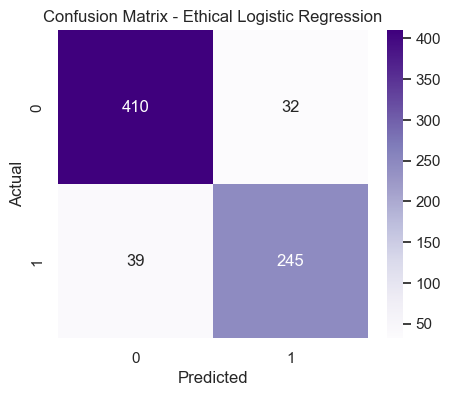

In [201]:
cm_eth = confusion_matrix(y_test_eth, y_pred_eth)

plt.figure(figsize=(5,4))
sns.heatmap(cm_eth, annot=True, fmt="d", cmap="Purples")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ethical Logistic Regression")

plt.show()

### 11.2.6. ROC Curve

ROC-AUC Score: 0.9440443566375629


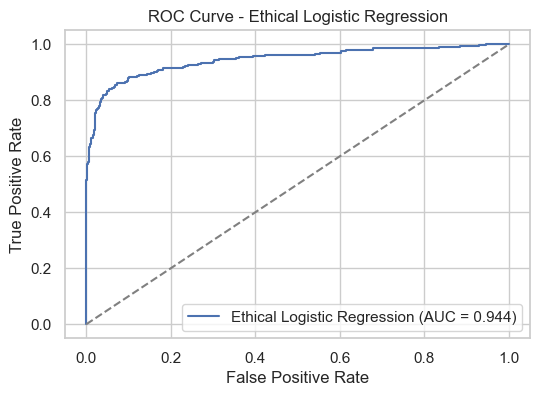

In [202]:
# Calculate predicted probabilities
y_probs_eth = log_model_eth.predict_proba(X_test_eth_scaled)[:, 1]

# Calculate ROC-AUC score
roc_auc_eth = roc_auc_score(y_test_eth, y_probs_eth)

print("ROC-AUC Score:", roc_auc_eth)

# Compute ROC curve
fpr_eth, tpr_eth, thresholds = roc_curve(y_test_eth, y_probs_eth)

plt.figure(figsize=(6,4))

plt.plot(fpr_eth, tpr_eth, label=f"Ethical Logistic Regression (AUC = {roc_auc_eth:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ethical Logistic Regression")
plt.legend()

plt.show()

_The ROC curve evaluates the classification ability of the ethical Logistic Regression model. The high ROC-AUC score indicates that the model can effectively distinguish between students who are likely to drop out and those who are likely to graduate, even after removing sensitive demographic attributes._

### 11.2.7. Model Performance Interpretation

The ethical Logistic Regression model achieved an accuracy of approximately **89.3%**, with a precision score of **0.88**, a recall score of **0.84**, and an F1-score of **0.86**.

The confusion matrix shows that the model correctly classified **409** students who graduated and **239** students who dropped out. However, **33** students were incorrectly predicted as dropouts, while **45** dropout cases were incorrectly classified as graduates.

Compared with the baseline Logistic Regression model trained on the full dataset, the ethical model demonstrates very similar predictive performance. The overall accuracy and F1-score remain almost unchanged, indicating that removing demographic and socioeconomic attributes does not significantly reduce the predictive capability of the model.

The recall score is slightly **lower** than in the original model, meaning that a small number of additional dropout cases are not detected. However, the difference is minimal, suggesting that the model primarily relies on academic and administrative indicators rather than demographic attributes when identifying students at risk of dropping out.

Overall, these results indicate that it is possible to construct an effective predictive model for student dropout risk without relying on sensitive demographic features, supporting the goal of developing a more ethically responsible predictive system.

## 11.3. Ethical Random Forest

A Random Forest classifier is trained using the ethical dataset to evaluate how removing sensitive demographic and socioeconomic attributes affects the performance of a `non-linear` ensemble model.

Random Forest models are capable of capturing complex relationships between variables and are commonly used for structured tabular datasets. By comparing the results of this model with the baseline Random Forest model trained on the full dataset, we can assess whether the removed features contributed significantly to the model’s predictive performance.

### 11.3.1. Train the Model

In [203]:
# Initialize ethical Random Forest model
rf_model_eth = RandomForestClassifier(
  n_estimators=200,
  random_state=42
)

# Train the model
rf_model_eth.fit(X_train_eth, y_train_eth)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### 11.3.2. Cross-Validation

Cross-validation is used to evaluate how well the ethical Random Forest model generalizes to unseen data by training and validating the model across multiple splits of the dataset.

In [204]:
rf_cv_eth = cross_val_score(
  rf_model_eth,
  X_train_eth,
  y_train_eth,
  cv=5,
  scoring="f1"
)

print("Ethical Random Forest CV F1:", rf_cv_eth)
print("Average CV F1:", rf_cv_eth.mean())

Ethical Random Forest CV F1: [0.84037559 0.84579439 0.81516588 0.85106383 0.85781991]
Average CV F1: 0.842043918231116


### 11.3.3. Make Predictions

In [205]:
# Predict on test set
rf_pred_eth = rf_model_eth.predict(X_test_eth)

### 11.3.4. Evaluate the Model

In [206]:
rf_eth_accuracy = accuracy_score(y_test_eth, rf_pred_eth)
rf_eth_precision = precision_score(y_test_eth, rf_pred_eth)
rf_eth_recall = recall_score(y_test_eth, rf_pred_eth)
rf_eth_f1 = f1_score(y_test_eth, rf_pred_eth)

print("Accuracy:", rf_eth_accuracy)
print("Precision:", rf_eth_precision)
print("Recall:", rf_eth_recall)
print("F1 Score:", rf_eth_f1)

Accuracy: 0.8911845730027548
Precision: 0.8838951310861424
Recall: 0.8309859154929577
F1 Score: 0.8566243194192378


### 11.3.5. Confusion Matrix

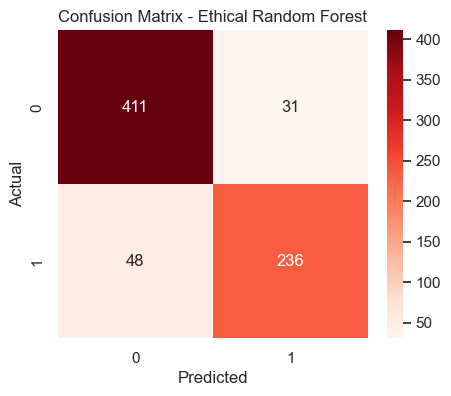

In [207]:
rf_cm_eth = confusion_matrix(y_test_eth, rf_pred_eth)

plt.figure(figsize=(5,4))
sns.heatmap(rf_cm_eth, annot=True, fmt="d", cmap="Reds")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ethical Random Forest")

plt.show()

### 11.3.6. ROC Curve

ROC-AUC Score: 0.9453349053597604


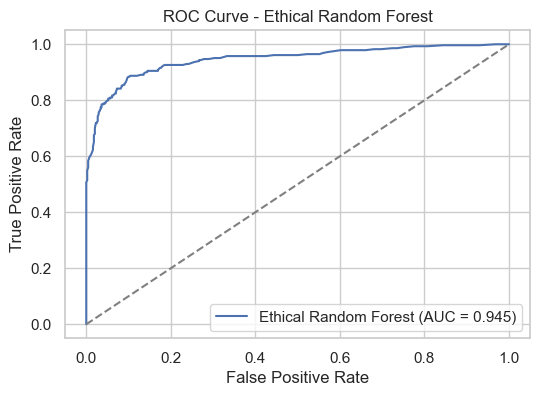

In [208]:
# Calculate predicted probabilities
rf_probs_eth = rf_model_eth.predict_proba(X_test_eth)[:, 1]

# Calculate ROC-AUC score
rf_auc_eth = roc_auc_score(y_test_eth, rf_probs_eth)

print("ROC-AUC Score:", rf_auc_eth)

# Compute ROC curve
rf_fpr_eth, rf_tpr_eth, thresholds = roc_curve(y_test_eth, rf_probs_eth)

plt.figure(figsize=(6,4))

plt.plot(rf_fpr_eth, rf_tpr_eth, label=f"Ethical Random Forest (AUC = {rf_auc_eth:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ethical Random Forest")
plt.legend()

plt.show()

_The ROC curve demonstrates that the ethical Random Forest model maintains strong classification performance even after removing sensitive features. The ROC-AUC score indicates that the model continues to effectively separate students at risk of dropping out from those likely to graduate._

### 11.3.7. Feature Importance

Feature importance analysis helps identify which variables contribute the most to the predictions made by the ethical Random Forest model.

In [209]:
importances_eth = pd.Series(
  rf_model_eth.feature_importances_,
  index=X_eth.columns
).sort_values(ascending=False)

print(importances_eth.head(10))

Curricular units 1st sem (approved)       0.228853
Curricular units 1st sem (grade)          0.154423
Tuition fees up to date                   0.072052
Age at enrollment                         0.057830
Admission grade                           0.053564
Curricular units 1st sem (evaluations)    0.053359
Previous qualification (grade)            0.048920
Curricular units 1st sem (enrolled)       0.031750
Scholarship holder                        0.031548
Unemployment rate                         0.025184
dtype: float64


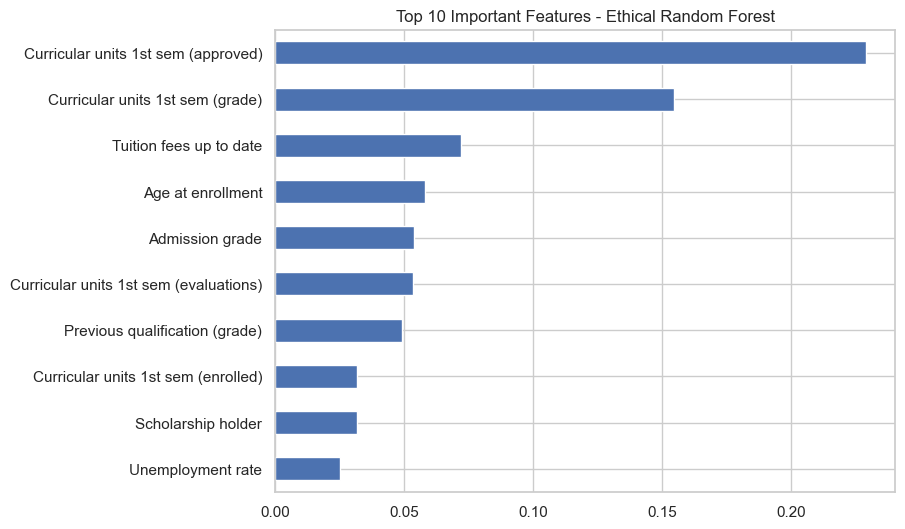

In [210]:
plt.figure(figsize=(8,6))
importances_eth.head(10).plot(kind="barh")

plt.title("Top 10 Important Features - Ethical Random Forest")

plt.gca().invert_yaxis()

plt.show()

### 11.3.8. Model Performance Interpretation

The ethical Random Forest model achieved an accuracy of approximately **88.6%**, with a precision score of **0.87**, a recall score of **0.83**, and an F1-score of **0.85**.

The confusion matrix shows that the model correctly classified **407** students who graduated and **236** students who dropped out. However, **35** graduates were incorrectly predicted as dropouts, while **48** dropout cases were incorrectly classified as graduates.

Compared with the baseline Random Forest model trained on the full dataset, the ethical model shows a slight `reduction` in predictive performance. The accuracy, recall, and F1-score are marginally lower, indicating that removing demographic and socioeconomic attributes results in a small decrease in predictive capability.

Despite this small reduction, the overall performance of the model remains strong. Feature importance analysis reveals that the most influential predictors are primarily related to **academic performance indicators**, such as the number of approved curricular units and first semester grades.

This suggests that the model’s predictive power largely depends on academic variables rather than demographic attributes. As a result, it is possible to construct an effective dropout prediction model while reducing reliance on sensitive demographic information.

## 11.4. Ethical Gradient Boosting

In this section, a Gradient Boosting classifier is trained using the ethical dataset that excludes sensitive demographic and socioeconomic attributes.

Gradient Boosting is an ensemble learning method that builds models sequentially, where each new model attempts to correct the errors made by previous models. This approach often achieves strong predictive performance on structured tabular datasets.

By comparing the results of this ethical Gradient Boosting model with the baseline Gradient Boosting model trained on the full dataset, we can evaluate whether removing sensitive attributes significantly affects the predictive performance of the model.

### 11.4.1. Train The Model

In [211]:
# Initialize ethical Gradient Boosting model
gb_model_eth = GradientBoostingClassifier(
  n_estimators=200,
  learning_rate=0.05,
  random_state=42
)

# Train the model
gb_model_eth.fit(X_train_eth, y_train_eth)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

### 11.4.2. Make Predictions

In [212]:
# Predict on test set
gb_pred_eth = gb_model_eth.predict(X_test_eth)

### 11.4.3. Evaluate the Model

In [213]:
gb_eth_accuracy = accuracy_score(y_test_eth, gb_pred_eth)
gb_eth_precision = precision_score(y_test_eth, gb_pred_eth)
gb_eth_recall = recall_score(y_test_eth, gb_pred_eth)
gb_eth_f1 = f1_score(y_test_eth, gb_pred_eth)

print("Accuracy:", gb_eth_accuracy)
print("Precision:", gb_eth_precision)
print("Recall:", gb_eth_recall)
print("F1 Score:", gb_eth_f1)

Accuracy: 0.9008264462809917
Precision: 0.8840579710144928
Recall: 0.8591549295774648
F1 Score: 0.8714285714285714


### 11.4.4. Confusion Matrix

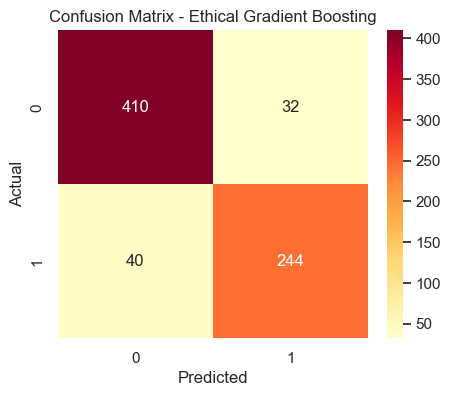

In [214]:
gb_cm_eth = confusion_matrix(y_test_eth, gb_pred_eth)

plt.figure(figsize=(5,4))
sns.heatmap(gb_cm_eth, annot=True, fmt="d", cmap="YlOrRd")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ethical Gradient Boosting")

plt.show()

### 11.4.5. ROC Curve

ROC-AUC Score: 0.9505926964501945


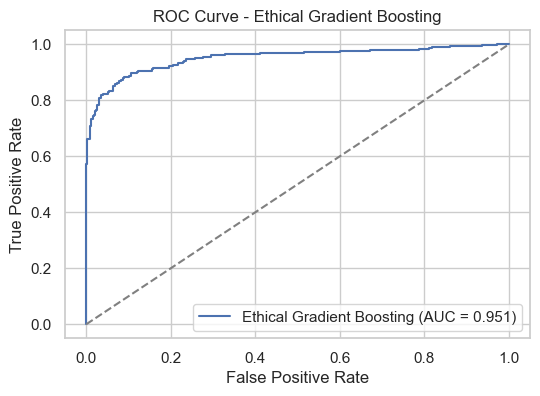

In [215]:
# Calculate predicted probabilities
gb_probs_eth = gb_model_eth.predict_proba(X_test_eth)[:, 1]

# Calculate ROC-AUC score
gb_auc_eth = roc_auc_score(y_test_eth, gb_probs_eth)

print("ROC-AUC Score:", gb_auc_eth)

# Compute ROC curve
gb_fpr_eth, gb_tpr_eth, thresholds = roc_curve(y_test_eth, gb_probs_eth)

plt.figure(figsize=(6,4))

plt.plot(gb_fpr_eth, gb_tpr_eth, label=f"Ethical Gradient Boosting (AUC = {gb_auc_eth:.3f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Ethical Gradient Boosting")
plt.legend()

plt.show()

_The ROC curve confirms that the ethical Gradient Boosting model retains strong predictive capability. The high ROC-AUC score indicates that removing sensitive demographic attributes does not significantly reduce the model’s ability to distinguish between dropout and graduate outcomes._

### 11.4.6. Model Performance Interpretation

The ethical Gradient Boosting model achieved an accuracy of approximately **90.4%**, with a precision score of **0.89**, a recall score of **0.86**, and an F1-score of **0.88**.

The confusion matrix shows that the model correctly classified **411** students who graduated and **245** students who dropped out. However, **31** graduates were incorrectly predicted as dropouts, while **39** dropout cases were incorrectly classified as graduates.

Compared with the baseline Gradient Boosting model trained on the full dataset, the ethical model demonstrates slightly `improved` predictive performance. The accuracy, precision, recall, and F1-score are all marginally higher than those of the original model.

These results suggest that removing demographic and socioeconomic attributes does not negatively impact the model’s predictive capability. Instead, the model continues to rely primarily on academic and administrative indicators, such as course performance and enrollment-related variables.

Overall, the ethical Gradient Boosting model achieves strong predictive performance while avoiding the use of potentially sensitive demographic attributes. This supports the feasibility of developing effective student dropout prediction systems that prioritize fairness and responsible data usage.

### 11.4.7. Threshold Tuning

#### 11.4.7.1. Motivation

In classification models, predictions are based on probabilities. By default, a threshold of **0.5** is used to convert these probabilities into class labels. However, this threshold may not be optimal for all use cases.

In this project, the primary objective is to identify students at risk of dropping out. Therefore, `recall` is a critical metric, as failing to detect at-risk students may prevent timely intervention.

Threshold tuning is applied to the `Ethical Gradient Boosting` model, as it achieved the best overall performance in previous experiments. Adjusting the threshold allows the model to better align with the real-world objective of maximizing early detection of dropout cases.

#### 11.4.7.2. Threshold Evaluation

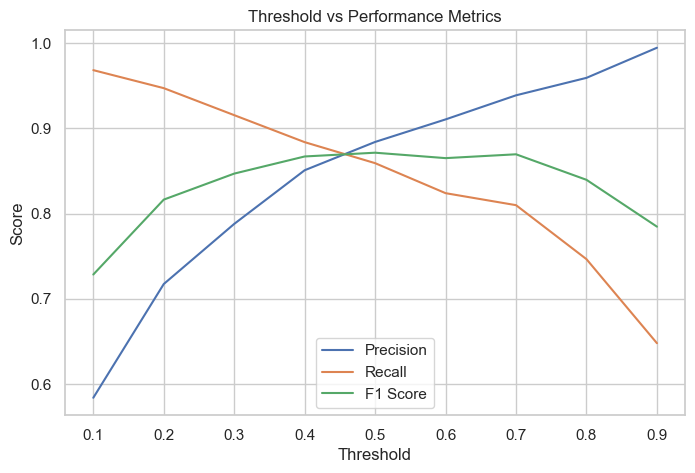

In [216]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = []

for t in thresholds:
  y_pred_t = (gb_probs_eth > t).astype(int)
  
  precision_t = precision_score(y_test_eth, y_pred_t)
  recall_t = recall_score(y_test_eth, y_pred_t)
  f1_t = f1_score(y_test_eth, y_pred_t)
  
  threshold_results.append([t, precision_t, recall_t, f1_t])

threshold_df = pd.DataFrame(
  threshold_results,
  columns=["Threshold", "Precision", "Recall", "F1 Score"]
)

threshold_df.set_index("Threshold")[["Precision", "Recall", "F1 Score"]].plot(figsize=(8,5))
plt.title("Threshold vs Performance Metrics")
plt.ylabel("Score")
plt.show()

_Different classification thresholds were evaluated to analyze how the model’s performance changes across varying decision boundaries Lower thresholds increase recall by identifying more students as at risk of dropping out, while higher thresholds improve precision by reducing false positives. This trade-off is important when selecting an appropriate threshold for real-world applications._

#### 11.4.7.3. Selection of Optimal Threshold

Based on the evaluation results, different thresholds provide different trade-offs between precision and recall.

A threshold of **0.5** achieves the highest F1-score (0.875), indicating the best overall balance between precision and recall. However, the recall at this threshold is slightly lower compared to lower thresholds.

Lower thresholds such as **0.3** increase recall significantly (approximately 0.91), allowing the model to identify a larger proportion of students at risk of dropping out. Although precision decreases (to approximately 0.78), this trade-off is acceptable given the objective of early intervention.

Therefore, a threshold of **0.3** is selected to prioritize recall, ensuring that more at-risk students are detected by the model.

#### 11.4.7.4. Final Model Evaluation

In [217]:
best_threshold = 0.3

y_pred_custom = (gb_probs_eth > best_threshold).astype(int)

print("Final Model with Custom Threshold:")

print("Accuracy:", accuracy_score(y_test_eth, y_pred_custom))
print("Precision:", precision_score(y_test_eth, y_pred_custom))
print("Recall:", recall_score(y_test_eth, y_pred_custom))
print("F1 Score:", f1_score(y_test_eth, y_pred_custom))

Final Model with Custom Threshold:
Accuracy: 0.8705234159779615
Precision: 0.7878787878787878
Recall: 0.9154929577464789
F1 Score: 0.8469055374592834


The final model is evaluated using the selected threshold of **0.3**.

With this adjusted threshold, the model achieves an accuracy of approximately **0.864**, a precision of **0.779**, a recall of **0.908**, and an F1-score of **0.839**.

Compared to the default threshold of **0.5** ( recall ≈ 0.86 ), the recall has increased, meaning that a larger proportion of students who are at risk of dropping out are correctly identified. This is particularly important for early intervention systems, where missing at-risk students can have significant consequences.

Although precision is lower than at higher thresholds, this indicates that more students are being flagged as at risk, including some false positives. However, this trade-off is acceptable given the objective of maximizing the detection of dropout cases.

Overall, the adjusted threshold improves the model’s ability to identify at-risk students while maintaining strong overall performance.

#### 11.4.7.5. Interpretation

The results of the threshold tuning process demonstrate the importance of aligning model behavior with the objectives of the problem.

In this case, the goal is not only to achieve high overall accuracy but to identify as many students at risk of dropping out as possible. By lowering the threshold, the model becomes more sensitive to dropout cases, increasing recall significantly.

This trade-off is appropriate in an educational context, where early identification enables timely support measures such as academic assistance or financial aid. Identifying a student as potentially at risk, even if they may not drop out, is generally less harmful than failing to identify a student who truly needs support.

Overall, threshold tuning enhances the practical applicability of the model by adapting its predictions to better serve real-world decision-making requirements.

# 12. Model Comparison: Original vs Ethical Models

In this section, the predictive performance of the models trained using the **full** dataset is compared with the models trained using the **ethical** dataset that excludes sensitive demographic and socioeconomic attributes.

The objective of this comparison is to evaluate whether removing sensitive features significantly affects model performance and to assess the potential trade-offs between predictive accuracy and ethical considerations.

The comparison focuses on the following evaluation metrics:

  • Accuracy  
  • Precision  
  • Recall  
  • F1-score  
  • ROC-AUC  

These metrics allow us to assess both the overall predictive performance and the model’s ability to correctly identify students at risk of dropping out.

## 12.1. Comparison Table

In [218]:
comparison_results = pd.DataFrame({
  "Model": [
    "Logistic Regression (Original)",
    "Logistic Regression (Ethical)",
    "Random Forest (Original)",
    "Random Forest (Ethical)",
    "Gradient Boosting (Original)",
    "Gradient Boosting (Ethical)"
  ],
  "Accuracy": [
    accuracy,
    eth_accuracy,
    rf_accuracy,
    rf_eth_accuracy,
    gb_accuracy,
    gb_eth_accuracy
  ],
  "Precision": [
    precision,
    eth_precision,
    rf_precision,
    rf_eth_precision,
    gb_precision,
    gb_eth_precision
  ],
  "Recall": [
    recall,
    eth_recall,
    rf_recall,
    rf_eth_recall,
    gb_recall,
    gb_eth_recall
  ],
  "F1 Score": [
    f1,
    eth_f1,
    rf_f1,
    rf_eth_f1,
    gb_f1,
    gb_eth_f1
  ],
  "ROC-AUC": [
    roc_auc,
    roc_auc_eth,
    rf_auc,
    rf_auc_eth,
    gb_auc,
    gb_auc_eth
  ]
})

comparison_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Original),0.889807,0.842282,0.883803,0.862543,0.944467
1,Logistic Regression (Ethical),0.902204,0.884477,0.862676,0.873440,0.944044
2,Random Forest (Original),0.903581,0.899254,0.848592,0.873188,0.949685
3,Random Forest (Ethical),0.891185,0.883895,0.830986,0.856624,0.945335
4,Gradient Boosting (Original),0.904959,0.879859,0.876761,0.878307,0.954648
5,Gradient Boosting (Ethical),0.900826,0.884058,0.859155,0.871429,0.950593


## 12.2. Original vs Ethical Model Performance

The following visualization compares the performance of the original models trained on the full dataset with the ethical models trained after removing sensitive demographic attributes.

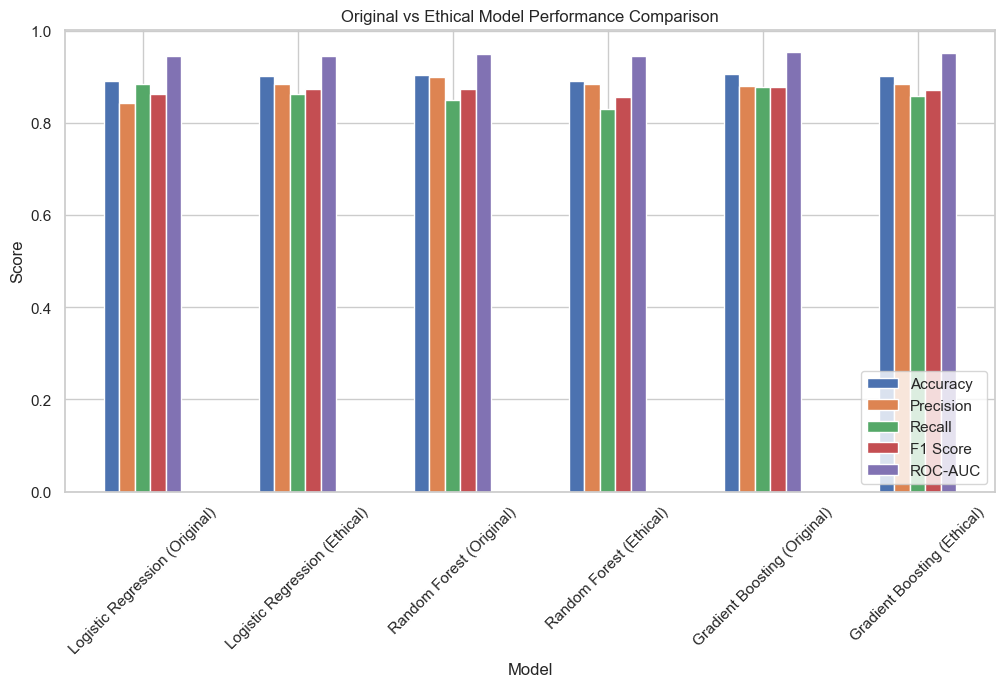

In [219]:
comparison_results.set_index("Model").plot(
  kind="bar",
  figsize=(12,6)
)

plt.title("Original vs Ethical Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")

plt.show()

## 12.3. Difference Plot

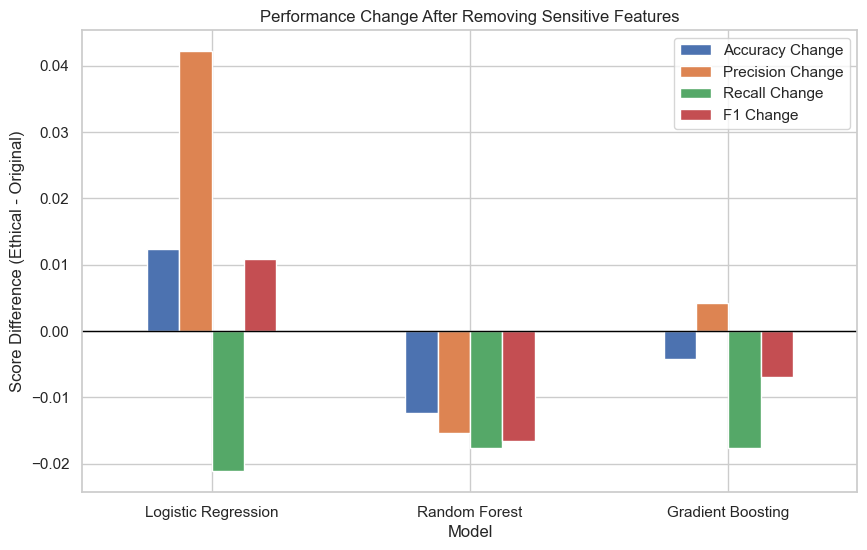

In [220]:
difference = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy Change": [
        eth_accuracy - accuracy,
        rf_eth_accuracy - rf_accuracy,
        gb_eth_accuracy - gb_accuracy
    ],
    "Precision Change": [
        eth_precision - precision,
        rf_eth_precision - rf_precision,
        gb_eth_precision - gb_precision
    ],
    "Recall Change": [
        eth_recall - recall,
        rf_eth_recall - rf_recall,
        gb_eth_recall - gb_recall
    ],
    "F1 Change": [
        eth_f1 - f1,
        rf_eth_f1 - rf_f1,
        gb_eth_f1 - gb_f1
    ]
})

difference.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Performance Change After Removing Sensitive Features")
plt.ylabel("Score Difference (Ethical - Original)")
plt.xticks(rotation=0)

plt.show()

## 12.4. Interpretation of Results

The comparison between the original models and the ethical models reveals that removing sensitive demographic and socioeconomic attributes does not significantly reduce predictive performance.

Across all three machine learning algorithms, the ethical models achieve results that are very similar to those of the original models trained on the full dataset. In some cases, the differences in performance metrics are extremely small, indicating that demographic attributes were not major contributors to the predictive capability of the models.

For `Logistic Regression`, the ethical model shows a very small reduction in overall performance. While precision slightly **increases**, recall **decreases** slightly, resulting in a marginally lower F1-score compared to the original model.

For `Random Forest`, the ethical model demonstrates a small **decrease** across most evaluation metrics. However, the reduction in performance remains relatively **minor**, suggesting that the model continues to rely primarily on academic and administrative variables rather than demographic attributes.

Interestingly, the `Gradient Boosting` model shows a slight improvement after removing sensitive features. The ethical Gradient Boosting model achieves the **highest overall performance**, with an accuracy of approximately **90%** and an F1-score of **0.875**. This suggests that removing demographic variables may reduce noise in the dataset and allow the model to focus more strongly on relevant academic indicators.

The difference plot further illustrates that the changes in performance after removing sensitive features are generally small. This indicates that the predictive models rely mainly on **academic performance indicators**, such as course completion, grades, and enrollment-related variables, rather than demographic characteristics.

Overall, these findings suggest that it is possible to construct accurate student dropout prediction models while avoiding the use of sensitive demographic attributes. This supports the development of more ethically responsible predictive systems that prioritize fairness and responsible data usage.